# SVM Classifier

## Import Libraries

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## Import dataset

In [5]:
df = pd.read_csv('pulsar_stars.csv')


## Exploratory Data Analysis

In [6]:
df.shape

(17898, 9)

In [7]:
df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [8]:
col_names = df.columns
col_names

Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

In [9]:
# remove leading spaces from column names
df.columns = df.columns.str.strip()

In [10]:
df.columns

Index(['Mean of the integrated profile',
       'Standard deviation of the integrated profile',
       'Excess kurtosis of the integrated profile',
       'Skewness of the integrated profile', 'Mean of the DM-SNR curve',
       'Standard deviation of the DM-SNR curve',
       'Excess kurtosis of the DM-SNR curve', 'Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

In [11]:
#remane column names
df.columns = ['IP Mean', 'IP Sd', 'IP Kurtosis', 'IP Skewness',
              'DM-SNR Mean', 'DM-SNR Sd', 'DM-SNR Kurtosis', 'DM-SNR Skewness',
              'target_class']

In [12]:
df.columns

Index(['IP Mean', 'IP Sd', 'IP Kurtosis', 'IP Skewness', 'DM-SNR Mean',
       'DM-SNR Sd', 'DM-SNR Kurtosis', 'DM-SNR Skewness', 'target_class'],
      dtype='object')

We can see that the column names are shortened. IP stands for `integrated profile` and DM-SNR stands for `delta modulation and signal to noise ratio`. Now, it is much more easy to work with the columns.

In [13]:
# check the distribution of targrt column
df['target_class'].value_counts()

target_class
0    16259
1     1639
Name: count, dtype: int64

In [14]:
# view the % distribution of target_class 
df['target_class'].value_counts() / float(len(df)) * 100

target_class
0    90.842552
1     9.157448
Name: count, dtype: float64

We can see that percentage of observations of the class label `0` and `1` is 90.84% and 9.16%. So, this is a class imbalanced problem. I will deal with that in later section.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   IP Mean          17898 non-null  float64
 1   IP Sd            17898 non-null  float64
 2   IP Kurtosis      17898 non-null  float64
 3   IP Skewness      17898 non-null  float64
 4   DM-SNR Mean      17898 non-null  float64
 5   DM-SNR Sd        17898 non-null  float64
 6   DM-SNR Kurtosis  17898 non-null  float64
 7   DM-SNR Skewness  17898 non-null  float64
 8   target_class     17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [16]:
## Explore missing values in variables
df.isnull().sum()

IP Mean            0
IP Sd              0
IP Kurtosis        0
IP Skewness        0
DM-SNR Mean        0
DM-SNR Sd          0
DM-SNR Kurtosis    0
DM-SNR Skewness    0
target_class       0
dtype: int64

9 variable in dataset 8 are continous and 1 is discrete which are dependent variable

## Outlier in Numerical variables

In [17]:
# view summary stats in numerical variable
round(df.describe(), 2)

,IP Mean,IP Sd,IP Kurtosis,IP Skewness,DM-SNR Mean,DM-SNR Sd,DM-SNR Kurtosis,DM-SNR Skewness,target_class
count,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00
mean,111.08,46.55,0.48,1.77,12.61,26.33,8.30,104.86,0.09
std,25.65,6.84,1.06,6.17,29.47,19.47,4.51,106.51,0.29
min,5.81,24.77,-1.88,-1.79,0.21,7.37,-3.14,-1.98,0.00
25%,100.93,42.38,0.03,-0.19,1.92,14.44,5.78,34.96,0.00
50%,115.08,46.95,0.22,0.20,2.80,18.46,8.43,83.06,0.00
75%,127.09,51.02,0.47,0.93,5.46,28.43,10.70,139.31,0.00
max,192.62,98.78,8.07,68.10,223.39,110.64,34.54,1191.00,1.00


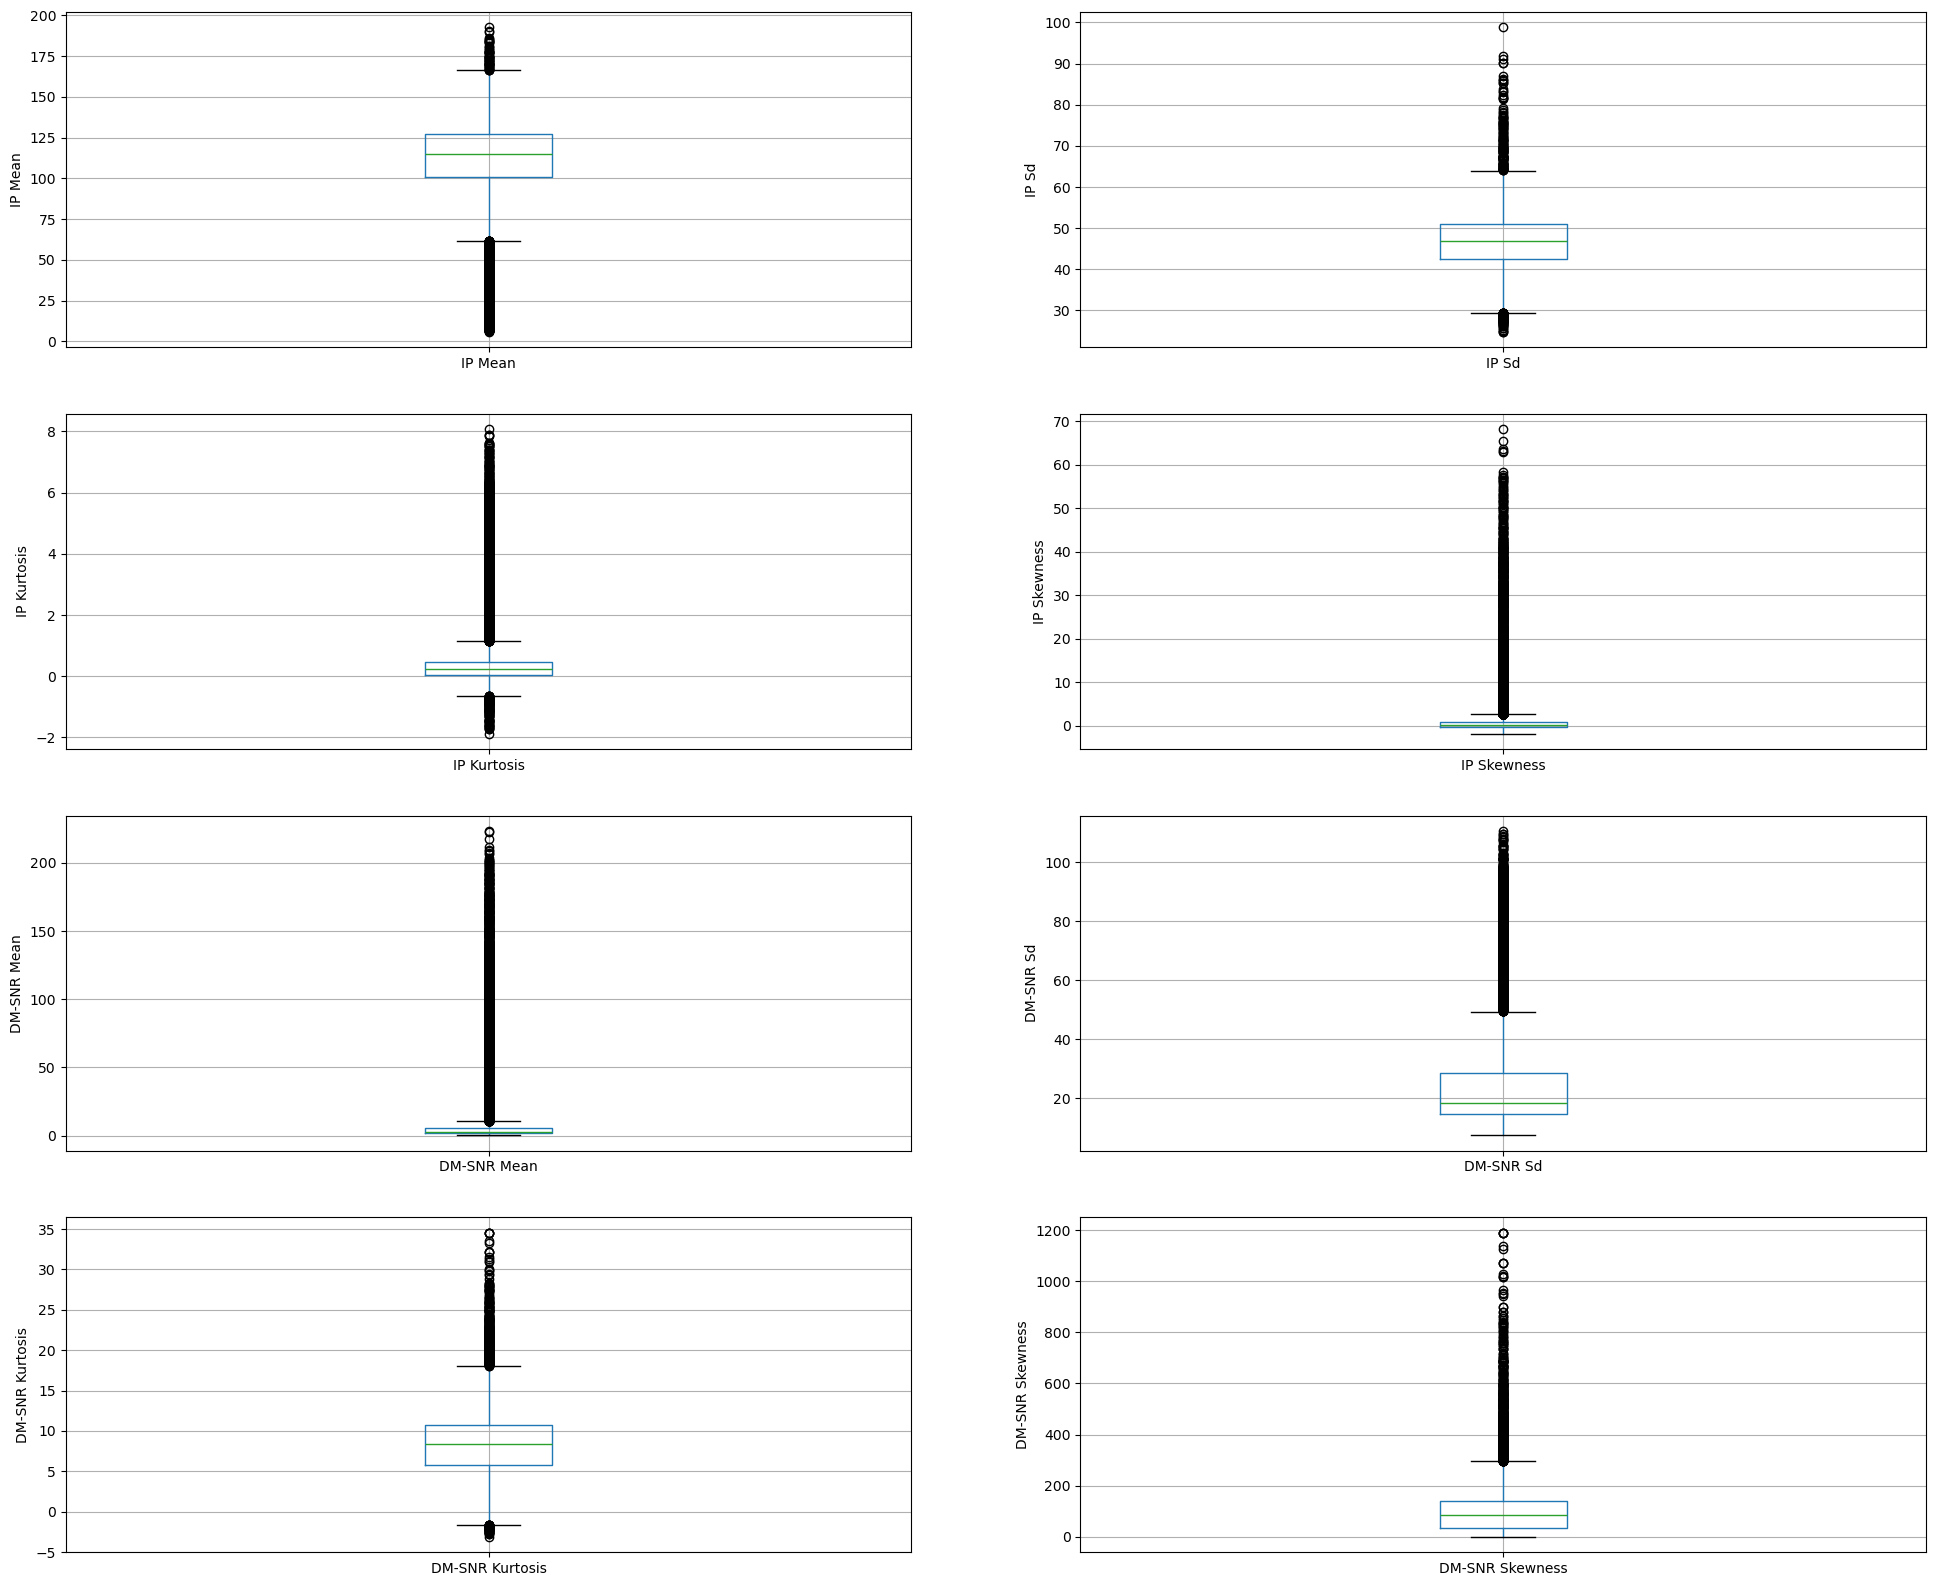

In [18]:
# draw box plot to visualize oulier

plt.figure(figsize=(24, 20))

plt.subplot(4, 2, 1)
fig = df.boxplot(column='IP Mean')
fig.set_title('')
fig.set_ylabel('IP Mean')

plt.subplot(4, 2, 2)
fig = df.boxplot(column='IP Sd')
fig.set_title('')
fig.set_ylabel('IP Sd')

plt.subplot(4, 2, 3)
fig = df.boxplot(column='IP Kurtosis')
fig.set_title('')
fig.set_ylabel('IP Kurtosis')

plt.subplot(4, 2, 4)
fig = df.boxplot(column='IP Skewness')
fig.set_title('')
fig.set_ylabel('IP Skewness')

plt.subplot(4, 2, 5)
fig = df.boxplot(column='DM-SNR Mean')
fig.set_title('')
fig.set_ylabel('DM-SNR Mean')

plt.subplot(4, 2, 6)
fig = df.boxplot(column='DM-SNR Sd')
fig.set_title('')
fig.set_ylabel('DM-SNR Sd')

plt.subplot(4, 2, 7)
fig = df.boxplot(column='DM-SNR Kurtosis')
fig.set_title('')
fig.set_ylabel('DM-SNR Kurtosis')

plt.subplot(4, 2, 8)
fig = df.boxplot(column='DM-SNR Skewness')
fig.set_title('')
fig.set_ylabel('DM-SNR Skewness')

plt.show()

There are lots of outlier 

## Check the distribution of variable

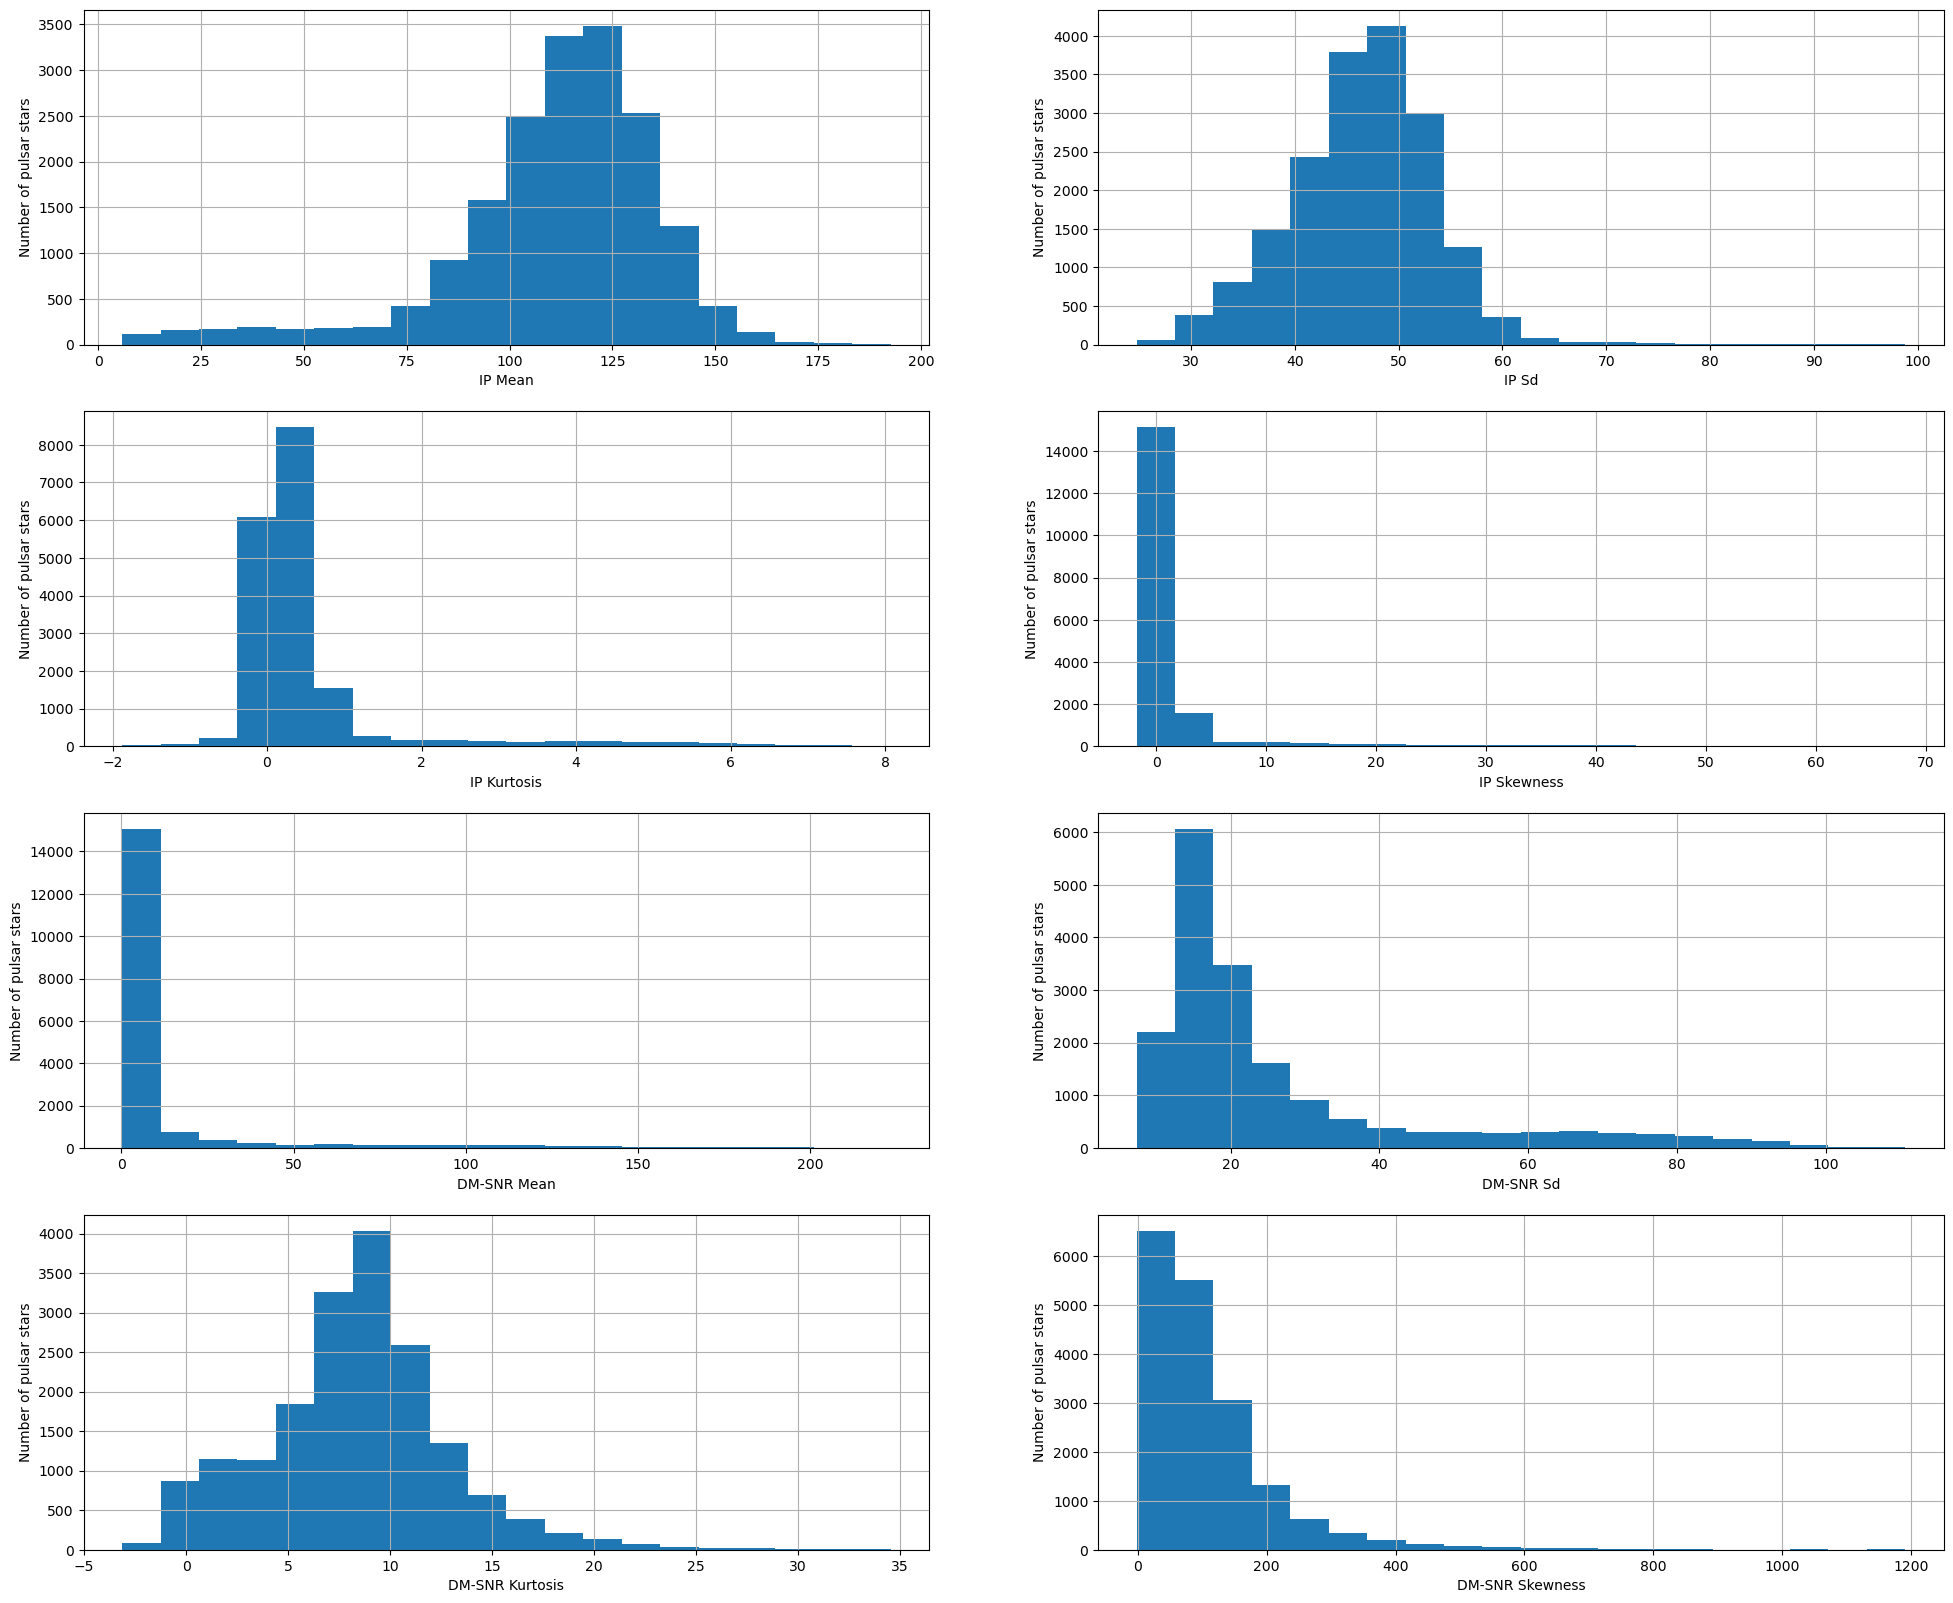

In [19]:
# plot histogram to check distribution

plt.figure(figsize=(24,20))

plt.subplot(4, 2, 1)
fig = df['IP Mean'].hist(bins = 20)
fig.set_xlabel('IP Mean')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 2)
fig = df['IP Sd'].hist(bins = 20)
fig.set_xlabel('IP Sd')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 3)
fig = df['IP Kurtosis'].hist(bins = 20)
fig.set_xlabel('IP Kurtosis')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 4)
fig = df['IP Skewness'].hist(bins = 20)
fig.set_xlabel('IP Skewness')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 5)
fig = df['DM-SNR Mean'].hist(bins = 20)
fig.set_xlabel('DM-SNR Mean')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 6)
fig = df['DM-SNR Sd'].hist(bins = 20)
fig.set_xlabel('DM-SNR Sd')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 7)
fig = df['DM-SNR Kurtosis'].hist(bins = 20)
fig.set_xlabel('DM-SNR Kurtosis')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 8)
fig = df['DM-SNR Skewness'].hist(bins = 20)
fig.set_xlabel('DM-SNR Skewness')
fig.set_ylabel('Number of pulsar stars')

plt.show()

## Declare feature vector and target variable

In [20]:
X = df.drop(['target_class'], axis=1)
y = df['target_class']

## Split data into separate training and test set

In [21]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

In [22]:
# check the shape of X_train and X_test
print(X_train.shape, X_test.shape)

(14318, 8) (3580, 8)


## Feature Scaling

In [23]:
cols = X_train.columns

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
X_train = pd.DataFrame(X_train, columns=[cols])
X_test = pd.DataFrame(X_test, columns=[cols])

In [26]:
X_train.describe()

,IP Mean,IP Sd,IP Kurtosis,IP Skewness,DM-SNR Mean,DM-SNR Sd,DM-SNR Kurtosis,DM-SNR Skewness
count,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04
mean,1.908113e-16,-6.550610e-16,1.042143e-17,3.870815e-17,-8.734147e-17,-1.617802e-16,-1.513588e-17,1.122785e-16
std,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00
min,-4.035499e+00,-3.181033e+00,-2.185946e+00,-5.744051e-01,-4.239001e-01,-9.733707e-01,-2.455649e+00,-1.003411e+00
25%,-3.896291e-01,-6.069473e-01,-4.256221e-01,-3.188054e-01,-3.664918e-01,-6.125457e-01,-5.641035e-01,-6.627590e-01
50%,1.587461e-01,5.846646e-02,-2.453172e-01,-2.578142e-01,-3.372294e-01,-4.067482e-01,3.170446e-02,-2.059136e-01
75%,6.267059e-01,6.501017e-01,-1.001238e-02,-1.419621e-01,-2.463724e-01,1.078934e-01,5.362759e-01,3.256217e-01
max,3.151882e+00,7.621116e+00,7.008906e+00,1.054430e+01,7.025568e+00,4.292181e+00,5.818557e+00,1.024613e+01


## Run SVM with default Hyperparameters

In [27]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svc = SVC()

# fit classifier to training set
svc.fit(X_train, y_train)

# make predictions on test set
y_pred = svc.predict(X_test)

print(f'Model accuracy score with default hyperparameters : {accuracy_score(y_test, y_pred):.4f}')

Model accuracy score with default hyperparameters : 0.9827


### Run SVM with rbf kernel and C=100.0


We have seen that there are outliers in our dataset. So, we should increase the value of C as higher C means fewer outliers. 
So, I will run SVM with kernel=`rbf` and C=100.0.

In [28]:
svc = SVC(C=100.0)

svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

print(f'Model accuracy score with rbf kernal and C=100.0 : {accuracy_score(y_test, y_pred):.4f}')


Model accuracy score with rbf kernal and C=100.0 : 0.9832


We can see that we obtain a higher accuracy with C=100.0 as higher C means less outliers.

## Run SVM with kernal rbf and C = 1000.0

In [29]:
svc = SVC(C=1000.0)

svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

print(f'Model accuracy score with rbf kernal and C=1000.0 : {accuracy_score(y_test, y_pred):.4f}')


Model accuracy score with rbf kernal and C=1000.0 : 0.9816


In this case, we can see that the accuracy had decreased with C=1000.0

## Run SVM with Linear kernal 

In [30]:
linear_svc = SVC(kernel='linear', C = 1.0)

linear_svc.fit(X_train, y_train)

y_pred_test = linear_svc.predict(X_test)

print(f'Model accuracy with linear kernal and C = 1.0 : {accuracy_score(y_test, y_pred_test):.4f}')

Model accuracy with linear kernal and C = 1.0 : 0.9830


## run SVM with linear kernal C = 100.0 

In [31]:
linear_svc100 = SVC(kernel='linear', C = 100.0)

linear_svc100.fit(X_train, y_train)

y_pred = linear_svc100.predict(X_test)

print(f'Model accuracy with linear kernal and C = 100.0 : {accuracy_score(y_test, y_pred):.4f}')

Model accuracy with linear kernal and C = 100.0 : 0.9832


## Run SVM with linear kernal and C = 1000.0

In [32]:
linear_svc1000 = SVC(kernel='linear', C = 1000.0)

linear_svc1000.fit(X_train, y_train)

y_pred = linear_svc1000.predict(X_test)

print(f'Model accuracy with linear kernal and C = 1000.0 : {accuracy_score(y_test, y_pred):.4f}')

Model accuracy with linear kernal and C = 1000.0 : 0.9832


> We can see that we can obtain higher accuracy with C=100.0 and C=1000.0 as compared to C=1.0.

Here, **y_test** are the true class labels and **y_pred** are the predicted class labels in the test-set.


### Compare the train-set and test-set accuracy


In [33]:
y_pred_train = linear_svc.predict(X_train)

print(y_pred_train)

print(f'Training-set accuracy score : {accuracy_score(y_train, y_pred_train):.4f}')

[0 0 1 ... 0 0 0]
Training-set accuracy score : 0.9783


Training set and test-set accuracy are very much comparable

## check for overfitting and underfitting

In [34]:
# print the scores on training and test set

print(f'Training set score : {linear_svc.score(X_train, y_train):.4f}')

print(f'Test set score : {linear_svc.score(X_test, y_test):.4f}')

Training set score : 0.9783
Test set score : 0.9830


The training-set accuracy score is 0.9783 while the test-set accuracy to be 0.9830. These two values are quite comparable. So, there is no question of overfitting. 

### Compare model accuracy with null accuracy


So, the model accuracy is 0.9832. But, we cannot say that our model is very good based on the above accuracy. We must compare it with the **null accuracy**. Null accuracy is the accuracy that could be achieved by always predicting the most frequent class.

So, we should first check the class distribution in the test set. 

In [35]:
y_test.value_counts()

target_class
0    3306
1     274
Name: count, dtype: int64

In [36]:
# check null accuracy score
null_accuracy = (3306/(3306+274))

print('Null accuracy score : {0:0.4f}'.format(null_accuracy))

Null accuracy score : 0.9235


## Run SVM with polynomial kernel

In [37]:
poly_svc  = SVC(kernel='poly')

# fit classifier to training set
poly_svc.fit(X_train, y_train)

y_pred = poly_svc.predict(X_test)

ac = accuracy_score(y_test, y_pred)

print(f'Model Accuracy score with poly kernel : {ac:0.4f}')

Model Accuracy score with poly kernel : 0.9807


## Run SVM with poly kernel and C = 100.0

In [38]:
poly_svc100  = SVC(kernel='poly', C=100.0)

# fit classifier to training set
poly_svc100.fit(X_train, y_train)

y_pred = poly_svc100.predict(X_test)

ac = accuracy_score(y_test, y_pred)

print(f'Model Accuracy score with poly kernel and C = 100 : {ac:0.4f}')

Model Accuracy score with poly kernel and C = 100 : 0.9824


## Run SVM with sigmoid kernel

In [39]:
sigmoid_svc = SVC(kernel='sigmoid')

sigmoid_svc.fit(X_train, y_train)

y_pred = sigmoid_svc.predict(X_test)

ac = accuracy_score(y_test, y_pred)

print(f'Model accuracy with sigmoid kernel : {ac:.4f}')

Model accuracy with sigmoid kernel : 0.8858


In [40]:
sigmoid_svc100 = SVC(kernel='sigmoid', C = 100.0)

sigmoid_svc100.fit(X_train, y_train)

y_pred = sigmoid_svc100.predict(X_test)

ac = accuracy_score(y_test, y_pred)

print(f'Model accuracy with sigmoid kernel and C = 100.0 : {ac:.4f}')

Model accuracy with sigmoid kernel and C = 100.0 : 0.8855


## Confusion Matrix

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

print('Confusion Matrix\n\n', cm)

print('\nTrue Positve (TP) =',cm[0,0])
print('\nTrue Negative (TN) =',cm[1,1])
print('\nFalse Positve (FP) =',cm[0,1])
print('\nFalse Negative (FN) =',cm[1,0])

Confusion Matrix

 [[3289   17]
 [  44  230]]

True Positve (TP) = 3289

True Negative (TN) = 230

False Positve (FP) = 17

False Negative (FN) = 44


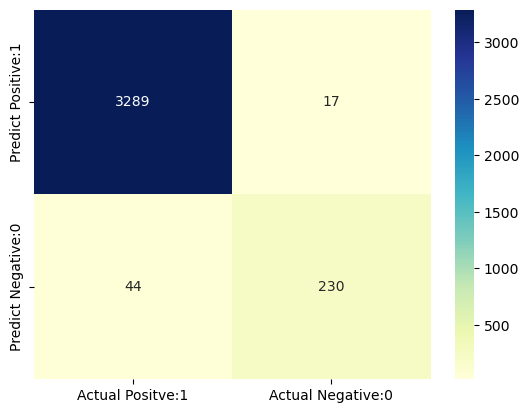

In [42]:
cm_matrix = pd.DataFrame(data = cm, columns= ['Actual Positve:1', 'Actual Negative:0'],
                         index= ['Predict Positive:1', 'Predict Negative:0'])
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.show()

## Classification Metrices

In [43]:
from sklearn.metrics import classification_report

print(f'classification report : ', classification_report(y_test, y_pred_test))

classification report :                precision    recall  f1-score   support

           0       0.99      0.99      0.99      3306
           1       0.93      0.84      0.88       274

    accuracy                           0.98      3580
   macro avg       0.96      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      3580



In [44]:
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

In [45]:
classification_accuracy = (TP+TN)/float(TP+TN+FP+FN)
print(f'Classification accuracy : {classification_accuracy:.4f}')

Classification accuracy : 0.9830


## Classification Error

In [46]:
classification_error = (FP+FN)/float(TP+TN+FP+FN)
print(f'Classification error : {classification_error:.4f}')

Classification error : 0.0170


## precision

In [47]:
precision = TP / (FP + TP)
print(f'Precision : {precision:.4f}')

Precision : 0.9949


## recall

In [48]:
recall = TP / (TP + FN)
print(f'Recall : {recall:.4f}')

Recall : 0.9868


## True Positive rate

In [49]:
true_positive_rate = TP / (TP+FN)
print(f'True Positve rate : {true_positive_rate:.4f}')

True Positve rate : 0.9868


## False Positive rate

In [50]:
false_positive_rate = FP / (FP + TN)
print(f'false_positive_rate : {false_positive_rate:.4f}')

false_positive_rate : 0.0688


## specificity

In [51]:
specificity = TN / (TN + FP)
print(f'Specificity : {specificity:.4f}')

Specificity : 0.9312


## f1 score

In [52]:
f1_score = 2 * precision * recall / (precision + recall)
print(f'F1 score : {f1_score:.4f}')

F1 score : 0.9908


## ROC-AUC 

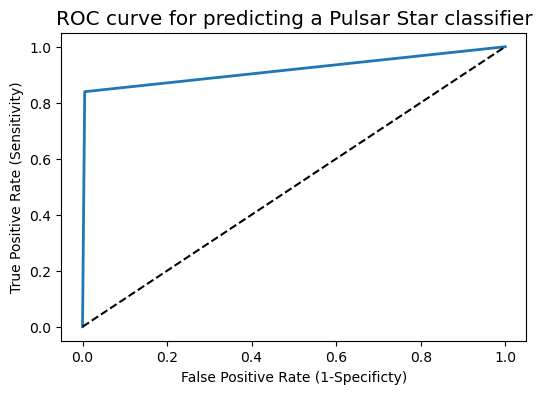

In [53]:
# plot the roc curve

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, linewidth = 2)
plt.plot([0,1],[0,1], 'k--')
plt.rcParams['font.size'] = 12
plt.title('ROC curve for predicting a Pulsar Star classifier')
plt.xlabel('False Positive Rate (1-Specificty)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.show()

## ROC AUC

In [54]:
from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_test, y_pred_test)

print(f'ROC AUC : {ROC_AUC:.4f}')

ROC AUC : 0.9171


In [55]:
from sklearn.model_selection import cross_val_score

Cross_validated_score = cross_val_score(linear_svc, X_train, y_train, cv=10, scoring='roc_auc').mean()
print(f'Cross validated ROC_AUC : {Cross_validated_score:.4f}')

Cross validated ROC_AUC : 0.9756


## Straitified k-fold Cross Validation with shuffle split

In [56]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True,random_state=0)

linear_svc = SVC(kernel='linear')
linear_scores = cross_val_score(linear_svc,X,y,cv =kfold)


In [57]:
print(f'Straitified cross-validated scores with linear kernel : \n\n {linear_scores}')

Straitified cross-validated scores with linear kernel : 

 [0.98296089 0.97458101 0.97988827 0.97876502 0.97848561]


In [58]:
print(f'Average straitified cross-validated score with linear kernel: {linear_scores.mean():.4f}')

Average straitified cross-validated score with linear kernel: 0.9789


## straitified k-Fold cross validated with shuffle split with rbf kernel

In [59]:
rbf_svc = SVC(kernel='rbf')

rbf_scores = cross_val_score(rbf_svc, X, y, cv = kfold)


In [60]:
print(f'Straitified cross-validated scores with rbf kernel : \n\n {rbf_scores}')

Straitified cross-validated scores with rbf kernel : 

 [0.97849162 0.97011173 0.97318436 0.9709416  0.96982397]


In [61]:
print(f'Average straitified cross-validated score with rbf kernel: {rbf_scores.mean():.4f}')

Average straitified cross-validated score with rbf kernel: 0.9725


## Hyperparameter Optimization using GridSearch CV

In [62]:
# import GridSearchCV
from sklearn.model_selection import GridSearchCV

# import SVC classifier
from sklearn.svm import SVC

# instantiate classifier with default hyperparameters with kernel=rbf, C=1.0 and gamma=auto
svc=SVC() 

# declare parameters for hyperparameter tuning
parameters = [ {'C':[1, 10, 100, 1000], 'kernel':['linear']},
               {'C':[1, 10, 100, 1000], 'kernel':['rbf'], 'gamma':[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]},
               {'C':[1, 10, 100, 1000], 'kernel':['poly'], 'degree': [2,3,4] ,'gamma':[0.01,0.02,0.03,0.04,0.05]} 
              ]
grid_search = GridSearchCV(estimator = svc,  
                           param_grid = parameters,
                           scoring = 'accuracy',
                           cv = 5,
                           verbose=0,n_jobs=-1)

grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid=[{'C': [1, 10, 100, 1000], 'kernel': ['linear']},
                         {'C': [1, 10, 100, 1000],
                          'gamma': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,
                                    0.9],
                          'kernel': ['rbf']},
                         {'C': [1, 10, 100, 1000], 'degree': [2, 3, 4],
                          'gamma': [0.01, 0.02, 0.03, 0.04, 0.05],
                          'kernel': ['poly']}],
             scoring='accuracy')

In [63]:
# examine the best model

# best score achieved during the GridSearchCV
print(f"GridSearch CV best score : {grid_search.best_score_:.4f}")

# print parameters that give the best results
print(f'Parameters that give the best result : {grid_search.best_params_}')

# print estimator that was chosen by the GridSearch
print(f'Estimator that was chosem by the search : {grid_search.best_estimator_}')


GridSearch CV best score : 0.9793
Parameters that give the best result : {'C': 10, 'gamma': 0.3, 'kernel': 'rbf'}
Estimator that was chosem by the search : SVC(C=10, gamma=0.3)


In [64]:
print(f'Gridsearch CV score on test set : {grid_search.score(X_test, y_test):.4f}')

Gridsearch CV score on test set : 0.9835
